Filename: Trifid-Red.FITS
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      71   (650, 500)   int16   


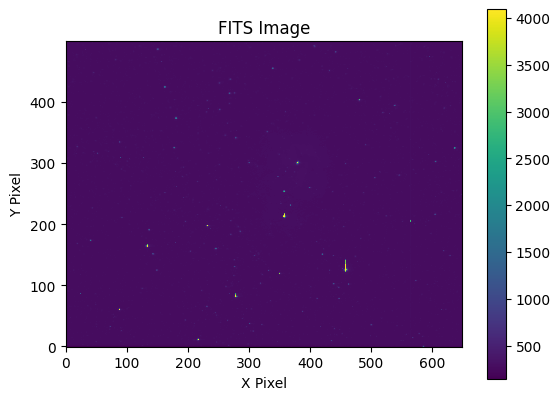

In [76]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize

# Specify the path to your FITS file
fits_file_path = 'Trifid-Red.FITS'

# Open the FITS file
with fits.open(fits_file_path) as hdul:
    # Print a summary of the file's contents
    hdul.info()
    
    # Extract the image data from the primary HDU
    image_data = hdul[0].data

#Normalize image
norm = ImageNormalize(stretch=SqrtStretch())

# Display the image data using matplotlib
plt.imshow(image_data, origin='lower', cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title('FITS Image')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()


In [ ]:
### For Stacked RGB FITS files 



from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# Specify the path to your FITS file
fits_file_path = 'File path.FITS'

# Open the FITS file
with fits.open(fits_file_path) as hdul:
    hdul.info()  # Check the structure of the FITS file
    image_data1 = hdul[0].data  # Access the stacked RGB data

# Check the shape of the data
print("Original shape of the data:", image_data1.shape)

# Rearrange the axes to (height, width, channels)
if image_data1.shape[0] == 3:  # Stacked as (channels, height, width)
    image_data1 = np.transpose(image_data, (1, 2, 0))

# Normalize the data for visualization (optional)
image_data1 = image_data / np.max(image_data)  # Scale data to [0, 1]

# Display the RGB image
plt.imshow(image_data1, origin='lower',  cmap='hot', interpolation='nearest')
plt.title('Stacked RGB FITS Image')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()


276.0
1.0


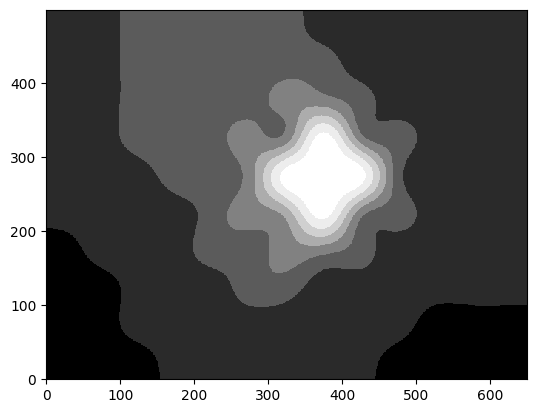

In [ ]:
from astropy.stats import SigmaClip, sigma_clipped_stats
from photutils.background import Background2D, MedianBackground

#Estimating Background using Sigma Clipping
sigmaclip = SigmaClip(sigma=3)

#Finding Median background
bkg_estimator = MedianBackground()
bkg = Background2D(image_data,(50, 50), filter_size=(3, 3),
                   sigma_clip=sigmaclip, bkg_estimator=bkg_estimator)
data = image_data - bkg.background

#Finding Sigma clipped stats
mean, median, std = sigma_clipped_stats(data, sigma=3.0)  
 
#Printing Background Median and RMS Median
print(bkg.background_median)  
print(bkg.background_rms_median)  

#Plotting Background
plt.imshow(bkg.background, origin='lower', cmap='Greys_r',
           interpolation='nearest')

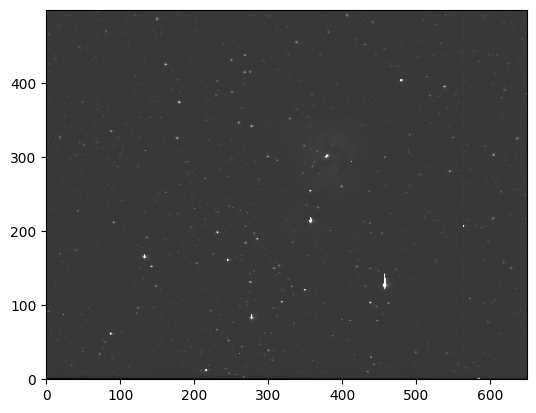

In [62]:
#Plotting Data without background
plt.imshow(data, origin='lower',norm=norm,
           cmap='Greys_r', interpolation='nearest')

In [71]:
#To detect sources from image, setting detection threshold using Background RMS and Convolving data using a 2D Gaussian Kernel

threshold = 12*bkg.background_rms

from astropy.convolution import convolve
from photutils.segmentation import make_2dgaussian_kernel
kernel = make_2dgaussian_kernel(4.0, size=5)  
convolved_data = convolve(data, kernel)

In [72]:
#Detecting sources

from photutils.segmentation import detect_sources
segment_map = detect_sources(convolved_data, threshold, npixels=10)
print(segment_map)

<photutils.segmentation.core.SegmentationImage>
shape: (500, 650)
nlabels: 348
labels: [  1   2   3   4   5 ... 344 345 346 347 348]


Text(0.5, 1.0, 'Segmentation Image')

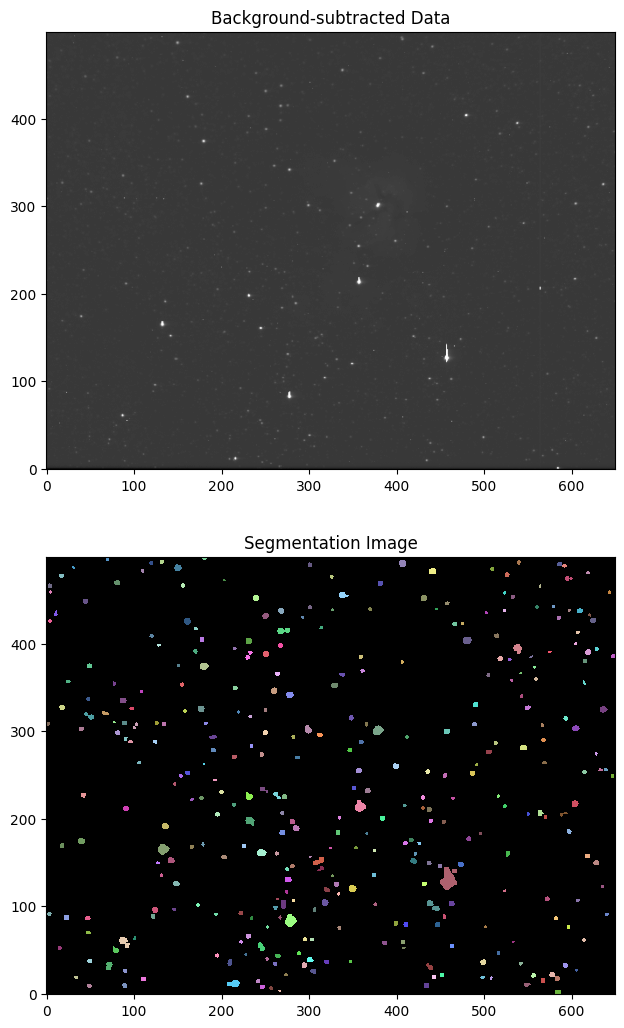

In [73]:
#Plotting the background-subtracted data and the segmentation image

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12.5))
ax1.imshow(data, origin='lower', cmap='Greys_r', norm=norm)
ax1.set_title('Background-subtracted Data')
ax2.imshow(segment_map, origin='lower', cmap=segment_map.cmap,
           interpolation='nearest')
ax2.set_title('Segmentation Image')

In [ ]:
#Making a source catalog 

from photutils.segmentation import SourceCatalog
cat = SourceCatalog(data, segment_map, convolved_data=convolved_data)
print(cat)
tbl = cat.to_table()
tbl['xcentroid'].info.format = '.2f'  # optional format
tbl['ycentroid'].info.format = '.2f'
tbl['kron_flux'].info.format = '.2f'

tbl.pprint(max_lines=-1, max_width=-1)

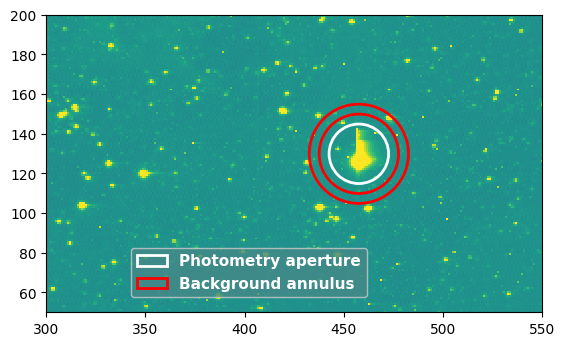

In [ ]:
'''
Selecting particular sources and inputting their positions
Plotting a photometry aperture and a background annulus for the source
'''

from astropy.visualization import simple_norm
from photutils.aperture import CircularAnnulus, CircularAperture
positions = [457.57, 129.88]
aperture = CircularAperture(positions, r=15)
annulus_aperture = CircularAnnulus(positions, r_in=20, r_out=25)

norm = simple_norm(data, 'sqrt', percent=99)
plt.imshow(data, norm=norm, interpolation='nearest')
plt.xlim(300,550)
plt.ylim(50, 200)

ap_patches = aperture.plot(color='white', lw=2,
                           label='Photometry aperture')
ann_patches = annulus_aperture.plot(color='red', lw=2,
                                    label='Background annulus')
handles = (ap_patches[0], ann_patches[0])
plt.legend(loc=(0.17, 0.05), facecolor='#458989', labelcolor='white',
           handles=handles, prop={'weight': 'bold', 'size': 11})

In [75]:
#Creating a table for positions and Aperture sums

from photutils.aperture import aperture_photometry
photo_table = aperture_photometry(data, aperture)
for col in photo_table.colnames:
    photo_table[col].info.format = '%.8g'  # for consistent table output
print(photo_table)

 id xcenter ycenter aperture_sum
      pix     pix               
--- ------- ------- ------------
  1  457.57  129.88    152938.34
